# LSTM temporel (TensorFlow/Keras) — prévision du **Heat Index** (NOAA GSOD, stations Maroc)

Approche **séries temporelles par station** en **TensorFlow/Keras**, inspirée de
`temporal_training/lstm_nasa_power.ipynb` mais **simplifiée** : un seul modèle
(**LSTM**) et une seule cible (**heat_index**).

À partir des `INPUT_WINDOW` derniers jours de variables météo, on prédit les
`OUTPUT_WINDOW` prochains jours du **heat_index**.

Pipeline : chargement des stations `data/cleandata_gsod_by_station` → nettoyage →
**heatmap de corrélation** → split chronologique par station 70/15/15 →
normalisation Min-Max (fit train only) → fenêtrage (par station) → **LSTM Keras** →
entraînement (`model.fit` + callbacks) → évaluation (RMSE/MAE/R²) → visualisation
→ sauvegarde (`.keras` + scalers).

## 0. Imports & configuration

In [34]:
import os, glob, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings; warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.18.1
GPU: []


In [35]:
# ── Configuration centrale (source de vérité unique) ──
from dataclasses import dataclass, field
from typing import List

@dataclass
class Config:
    """Hyperparamètres, chemins, features et cible du modèle LSTM (NOAA GSOD).
    Modifier ICI se propage à tout le notebook."""
    # — Données / chemins —
    data_dir: str = ""            # résolu automatiquement ci-dessous
    art_dir:  str = "artifacts"
    # — Features & cible (sélectionnées PAR NOM) —
    features: List[str] = field(default_factory=lambda: [
        "latitude", "longitude", "elevation",
        "tmax_c", "dewp_c", "humidity_pct",
        "wind_speed_ms", "press_hpa", "heat_index"
    ])
    target: str = "heat_index"
    # — Filtre saisonnier (mois inclus, 1-12) : 4->9 = avril à septembre —
    month_start: int = 1
    month_end:   int = 12
    # — Fenêtrage temporel —
    input_window:  int = 7        # jours passés fournis au modèle
    output_window: int = 7        # jours prédits
    # — Split chronologique par station (70 / 15 / 15) —
    train_ratio: float = 0.70
    val_ratio:   float = 0.15
    test_ratio:  float = 0.15
    # — Modèle —
    hidden:   int = 128
    n_layers: int = 2
    dropout:  float = 0.2
    # — Entraînement —
    batch_size: int = 256
    epochs:     int = 30
    lr:         float = 1e-3
    patience:   int = 15
    seed:       int = 42

    @property
    def n_features(self) -> int: return len(self.features)

cfg = Config()

# Résolution robuste du dossier de données (relatif au repo, peu importe où tourne le kernel)
_here = Path.cwd()
_candidates = [
    Path(cfg.data_dir) if cfg.data_dir else None,
    _here / "data" / "cleandata_gsod_by_station",
    _here.parent / "data" / "cleandata_gsod_by_station",
    _here.parent.parent / "data" / "cleandata_gsod_by_station",
]
DATA_DIR = next((str(p) for p in _candidates if p and Path(p).is_dir()), None)
assert DATA_DIR, "Dossier data/cleandata_gsod_by_station introuvable"
cfg.data_dir = DATA_DIR

ART_DIR = Path(cfg.art_dir); ART_DIR.mkdir(exist_ok=True)

# Alias courts (utilisés dans tout le notebook)
FEATURES, TARGET   = cfg.features, cfg.target
MONTH_START, MONTH_END = cfg.month_start, cfg.month_end
INPUT_WINDOW, OUTPUT_WINDOW = cfg.input_window, cfg.output_window
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = cfg.train_ratio, cfg.val_ratio, cfg.test_ratio
HIDDEN, N_LAYERS, DROPOUT = cfg.hidden, cfg.n_layers, cfg.dropout
BATCH_SIZE, EPOCHS, LR, PATIENCE = cfg.batch_size, cfg.epochs, cfg.lr, cfg.patience

print("DATA_DIR:", DATA_DIR)
print("features:", FEATURES)
print("target  :", TARGET)

DATA_DIR: /home/asmaoui/Documents/GitHub/PFE-Systeme-Alerte-Precoce-Maroc/data/cleandata_gsod_by_station
features: ['latitude', 'longitude', 'elevation', 'tmax_c', 'dewp_c', 'humidity_pct', 'wind_speed_ms', 'press_hpa', 'heat_index']
target  : heat_index


## 1. Chargement de toutes les stations

In [36]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
assert files, f"Aucun CSV dans {DATA_DIR}"
frames = []
for f in files:
    df = pd.read_csv(f, parse_dates=["date"])
    df["station"] = Path(f).stem
    frames.append(df)
data = pd.concat(frames, ignore_index=True)
print("stations:", data["station"].nunique(), "| lignes:", len(data))
print("période:", data["date"].min().date(), "->", data["date"].max().date())
data.head()

stations: 26 | lignes: 324069
période: 1990-01-01 -> 2025-08-24


,station_id,station_name,date,latitude,longitude,elevation,distance_to_ocean_km,tmax_c,tmin_c,tmean_c,dewp_c,humidity_pct,precip_mm,wind_speed_ms,press_hpa,heat_index,wind_chill,station
0,60155099999,Anfa,1990-01-01,33.556981,-7.660492,61.87,6.790714,19.000000,9.500000,13.777778,12.277778,90.665587,0.000,4.321330,1023.1,19.322935,7.229019,ANF_cleaned
1,60155099999,Anfa,1990-01-02,33.556981,-7.660492,61.87,6.790714,20.277778,10.000000,14.666667,12.277778,85.596693,0.000,4.424218,1021.7,20.596136,7.803991,ANF_cleaned
2,60155099999,Anfa,1990-01-03,33.556981,-7.660492,61.87,6.790714,14.888889,11.722222,13.111111,10.444444,83.868071,25.908,6.121884,1018.0,14.623222,11.722222,ANF_cleaned
3,60155099999,Anfa,1990-01-04,33.556981,-7.660492,61.87,6.790714,16.500000,8.500000,11.777778,9.277778,84.657247,10.922,2.932331,1025.2,16.416050,6.738982,ANF_cleaned
4,60155099999,Anfa,1990-01-05,33.556981,-7.660492,61.87,6.790714,16.722222,6.722222,12.000000,8.444444,78.862651,4.064,3.240997,1026.4,16.509191,4.401483,ANF_cleaned


## 2. Nettoyage & filtre saisonnier
Tri chronologique par station, **filtrage sur la saison chaude** (mois
`MONTH_START`..`MONTH_END`, par défaut 4→9 — période pertinente pour le heat index)
puis suppression des lignes ayant un NaN dans une colonne utilisée (features + cible).

In [37]:
def filter_months(df, start=MONTH_START, end=MONTH_END):
    """Ne garde que les lignes dont le mois est dans [start, end] (bornes incluses).
    Gère aussi les plages qui traversent le nouvel an (ex. start=11, end=2)."""
    m = df["date"].dt.month
    mask = (m >= start) & (m <= end) if start <= end else (m >= start) | (m <= end)
    return df[mask]

data = data.sort_values(["station", "date"]).reset_index(drop=True)

before = len(data)
data = filter_months(data).reset_index(drop=True)
print(f"filtre mois {MONTH_START}->{MONTH_END} : {before} -> {len(data)} lignes")

need = FEATURES + [TARGET]
before = len(data)
data = data.dropna(subset=need).reset_index(drop=True)
print(f"supprimé {before - len(data)} lignes NaN -> {len(data)} lignes")
data[need].describe().round(2)

filtre mois 1->12 : 324069 -> 324069 lignes
supprimé 22740 lignes NaN -> 301329 lignes


,latitude,longitude,elevation,tmax_c,dewp_c,humidity_pct,wind_speed_ms,press_hpa,heat_index,heat_index
count,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00
mean,32.24,-7.31,319.59,24.37,11.24,64.55,3.62,1010.16,25.30,25.30
std,3.03,3.28,369.89,6.39,5.98,18.66,2.24,25.59,8.01,8.01
min,23.70,-15.93,3.04,-0.39,-24.22,3.59,0.00,904.40,-1.94,-1.94
25%,30.94,-9.41,59.00,19.78,7.78,53.49,2.16,1012.90,19.66,19.66
50%,33.37,-6.75,199.03,23.89,11.94,69.10,3.09,1016.10,24.06,24.06
75%,34.79,-4.98,472.00,28.38,15.89,78.66,4.48,1019.60,30.32,30.32
max,35.59,-1.92,1515.00,50.22,25.78,100.00,22.74,1040.20,103.80,103.80


## 2bis. Matrice de corrélation (features & cible)
Heatmap de Pearson (seaborn) sur le jeu complet **après** nettoyage — pour repérer
la redondance entre features et les liens avec la cible `heat_index` avant
l'entraînement.

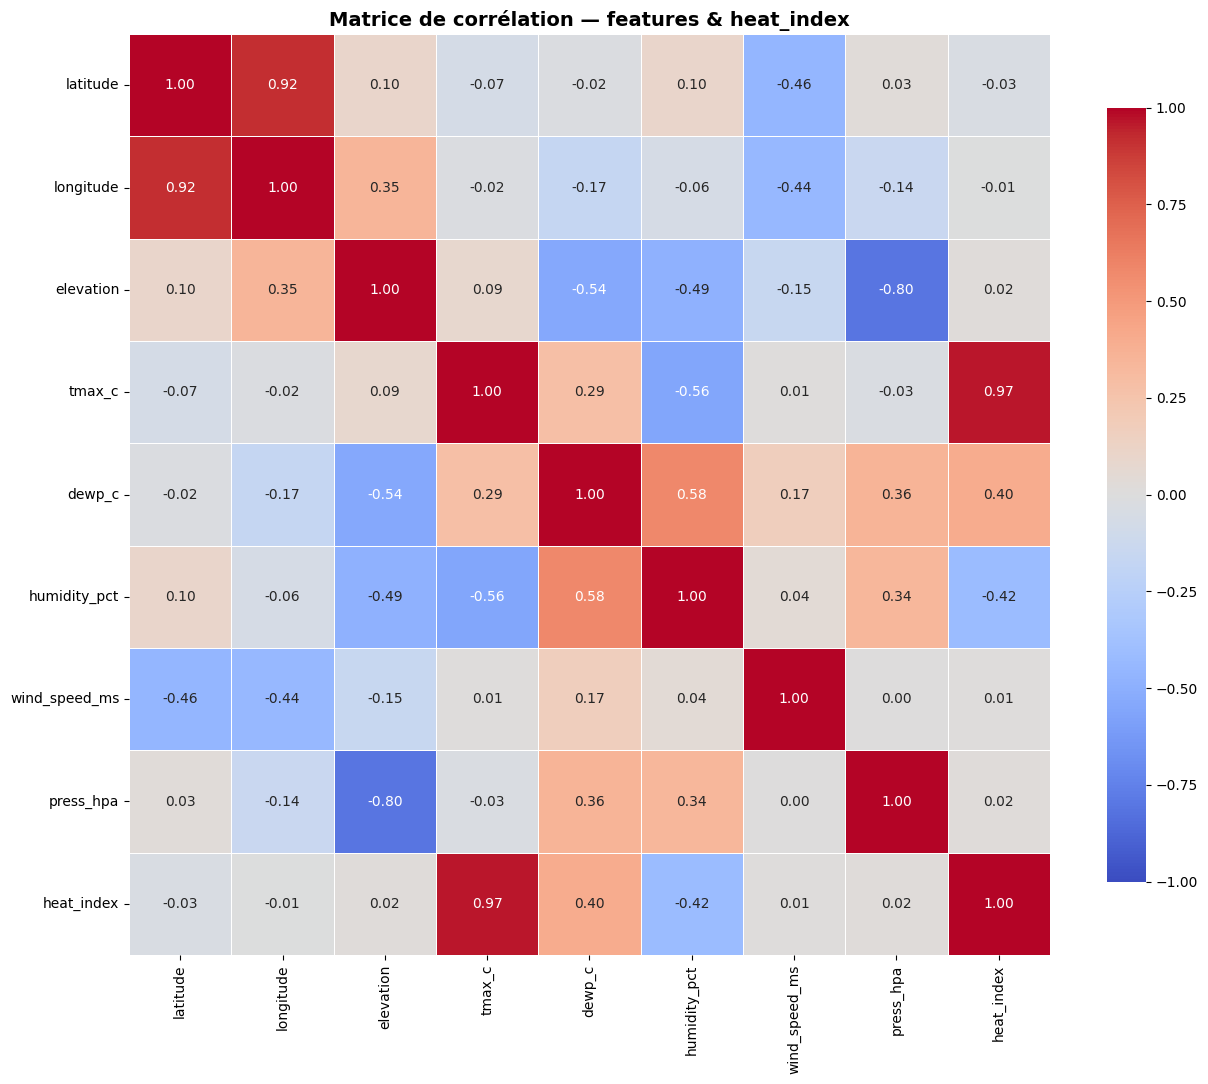

Paires |r| > 0.9 (redondance potentielle):
            heat_index ~ tmax_c               r=+0.966
             longitude ~ latitude             r=+0.918

Top |r| avec heat_index:
tmax_c           0.966
humidity_pct    -0.421
dewp_c           0.403
latitude        -0.033
press_hpa        0.022
elevation        0.020
wind_speed_ms    0.011
longitude       -0.007


In [38]:
# ── Heatmap de corrélation complète (features + cible) ──
corr_cols = FEATURES
corr = data[corr_cols].corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matrice de corrélation — features & heat_index", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# Paires fortement colinéaires (|r| > 0.9, hors diagonale) -> redondance potentielle
keep = np.tril(np.ones_like(corr, dtype=bool), k=-1)
pairs = corr.where(keep).abs().stack().sort_values(ascending=False)
pairs = pairs[pairs > 0.9]
print("Paires |r| > 0.9 (redondance potentielle):")
for (a, b), _ in pairs.items():
    print(f"  {a:>20s} ~ {b:<20s} r={corr.loc[a, b]:+.3f}")

# Top corrélations (|r|) de la cible avec les features
order = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(8).index
print(f"\nTop |r| avec {TARGET}:")
print(corr.loc[order, TARGET].round(3).to_string())

## 3. Split chronologique par station — 70 / 15 / 15
On découpe **chaque station** dans l'ordre temporel : 70 % (train), puis 15 %
(val), puis 15 % (test). Pas de mélange aléatoire, pas de chevauchement de stations
entre les jeux — chaque jeu reste contigu dans le temps (évite la fuite de données).

In [39]:
def split_station(g):
    g = g.sort_values("date")
    n = len(g)
    i_tr = int(n * TRAIN_RATIO)
    i_va = int(n * (TRAIN_RATIO + VAL_RATIO))
    return g.iloc[:i_tr], g.iloc[i_tr:i_va], g.iloc[i_va:]

parts = [split_station(g) for _, g in data.groupby("station")]
train_df = pd.concat([p[0] for p in parts], ignore_index=True)
val_df   = pd.concat([p[1] for p in parts], ignore_index=True)
test_df  = pd.concat([p[2] for p in parts], ignore_index=True)

tot = len(data)
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(d):7d} lignes ({len(d)/tot*100:4.1f}%)  "
          f"{d['date'].min().date()} -> {d['date'].max().date()}")

train:  210927 lignes (70.0%)  1990-01-01 -> 2019-06-14
val  :   45199 lignes (15.0%)  2012-06-06 -> 2022-07-19
test :   45203 lignes (15.0%)  2017-03-28 -> 2025-08-24


## 4. Normalisation Min-Max (fit sur TRAIN uniquement)
`MinMaxScaler` sur les features et sur la cible, ajusté **seulement** sur le train
(pas de fuite). Le scaler de la cible est conservé pour l'inverse-transform.

In [40]:
scaler_X = MinMaxScaler().fit(train_df[FEATURES])
scaler_y = MinMaxScaler().fit(train_df[[TARGET]])

def scale(df):
    df = df.copy()
    df[FEATURES] = scaler_X.transform(df[FEATURES])
    df[TARGET]   = scaler_y.transform(df[[TARGET]])
    return df

train_n, val_n, test_n = scale(train_df), scale(val_df), scale(test_df)
print("features range (train, post-scale):",
      float(train_n[FEATURES].min().min()), "->", float(train_n[FEATURES].max().max()))
print(f"{TARGET} data_min_ / data_max_:",
      round(float(scaler_y.data_min_[0]), 2), "/", round(float(scaler_y.data_max_[0]), 2))

features range (train, post-scale): 0.0 -> 1.0
heat_index data_min_ / data_max_: -1.94 / 103.8


## 5. Fenêtrage — séquences glissantes par station
Les fenêtres ne traversent jamais une frontière de station. X = `INPUT_WINDOW`
jours de features ; y = les `OUTPUT_WINDOW` jours suivants de la cible.

In [41]:
def make_sequences(df_norm):
    Xs, Ys = [], []
    win = INPUT_WINDOW + OUTPUT_WINDOW
    for _, g in df_norm.groupby("station"):
        g = g.sort_values("date")
        F = g[FEATURES].to_numpy(np.float32)
        T = g[TARGET].to_numpy(np.float32)
        for i in range(len(g) - win + 1):
            Xs.append(F[i:i+INPUT_WINDOW])
            Ys.append(T[i+INPUT_WINDOW:i+win])
    if not Xs:
        return (np.empty((0, INPUT_WINDOW, len(FEATURES)), np.float32),
                np.empty((0, OUTPUT_WINDOW), np.float32))
    return np.stack(Xs), np.stack(Ys)

X_tr, y_tr = make_sequences(train_n)
X_va, y_va = make_sequences(val_n)
X_te, y_te = make_sequences(test_n)
print("X_train:", X_tr.shape, "y_train:", y_tr.shape)
print("X_val  :", X_va.shape, "| X_test:", X_te.shape)

X_train: (210615, 7, 9) y_train: (210615, 7)
X_val  : (44887, 7, 9) | X_test: (44891, 7, 9)


## 6. Modèle LSTM (Keras)
LSTM empilé (`N_LAYERS` couches) suivi d'une tête dense qui produit les
`OUTPUT_WINDOW` valeurs de heat_index. Interface : `(INPUT_WINDOW, n_features) -> (OUTPUT_WINDOW,)`.

In [42]:
def build_lstm():
    inp = keras.Input(shape=(INPUT_WINDOW, len(FEATURES)))
    x = inp
    for li in range(N_LAYERS):
        x = layers.LSTM(HIDDEN, return_sequences=(li < N_LAYERS - 1))(x)
        x = layers.Dropout(DROPOUT)(x)
    out = layers.Dense(OUTPUT_WINDOW)(x)      # une valeur par horizon J+1..J+OUTPUT_WINDOW
    model = keras.Model(inp, out, name="LSTM_heat_index")
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="mse", metrics=["mae"])
    return model

# from tensorflow.keras import regularizers

# def build_lstm():
#     inp = keras.Input(shape=(INPUT_WINDOW, len(FEATURES)))
#     x = inp
#     for li in range(N_LAYERS):
#         x = layers.LSTM(
#             HIDDEN, 
#             return_sequences=(li < N_LAYERS - 1),
#             kernel_regularizer=regularizers.l2(0.005),    # <--- AJOUT LUKIĆ
#             recurrent_regularizer=regularizers.l2(0.005), # <--- AJOUT LUKIĆ
#             bias_regularizer=regularizers.l2(0.005)       # <--- AJOUT LUKIĆ
#         )(x)
#         # x = layers.Dropout(DROPOUT)(x) # Désactivé si on utilise L2
        
#     out = layers.Dense(OUTPUT_WINDOW)(x)
#     model = keras.Model(inp, out, name="LSTM_heat_index")
#     model.compile(optimizer=keras.optimizers.Adam(LR), loss="mse", metrics=["mae"])
#     return model

model = build_lstm()
model.summary()

Model: "LSTM_heat_index"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 7, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 7, 128)         │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,143 (793.53 KB)

 Trainable params: 203,143 (793.53 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entraînement
`model.fit` avec early stopping, réduction du learning rate, **checkpoints de reprise**
(BackupAndRestore : reprise automatique à l'epoch interrompue) et sauvegarde du
meilleur modèle. L'epoch d'arrêt est enregistrée dans `LSTM_resume.json`.

In [43]:
CKPT_DIR = ART_DIR / "checkpoints"; CKPT_DIR.mkdir(exist_ok=True)
BACKUP_DIR = CKPT_DIR / "backup_LSTM"      # état complet (poids+optimiseur+epoch) pour reprise auto

es = EarlyStopping(monitor="val_loss", patience=PATIENCE,
                   restore_best_weights=True, verbose=1)
callbacks = [
    es,
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=max(2, PATIENCE // 2), min_lr=1e-6, verbose=1),
    # Reprise après coupure : BackupAndRestore sauve l'état COMPLET (poids + optimiseur
    # + epoch) à chaque epoch et, au redémarrage du notebook, reprend AUTOMATIQUEMENT
    # à l'epoch interrompue. (Le dossier de backup est supprimé à la fin d'un run réussi.)
    keras.callbacks.BackupAndRestore(backup_dir=str(BACKUP_DIR)),
    # Meilleur modèle rencontré (selon val_loss) -> checkpoint réutilisable
    keras.callbacks.ModelCheckpoint(str(CKPT_DIR / "LSTM_best.keras"),
                                    monitor="val_loss", save_best_only=True, verbose=0),
    # Historique persistant par epoch (append -> survit aux coupures)
    keras.callbacks.CSVLogger(str(CKPT_DIR / "LSTM_history.csv"), append=True),
]

history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    callbacks=callbacks, verbose=1)

# ── Où l'entraînement s'est arrêté (epoch) + info de reprise ──
n_run      = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
resume = {"epochs_run": n_run, "best_epoch": best_epoch,
          "early_stopped_epoch": int(es.stopped_epoch) or None,
          "stop_reason": "early_stopping" if es.stopped_epoch else "epochs_terminees",
          "backup_dir": str(BACKUP_DIR),
          "best_checkpoint": str(CKPT_DIR / "LSTM_best.keras")}
json.dump(resume, open(CKPT_DIR / "LSTM_resume.json", "w"), indent=2)
print(f"epochs effectuées: {n_run} | meilleure epoch (val_loss): {best_epoch} "
      f"| arrêt: {resume['stop_reason']}")
print("Reprise auto ->", BACKUP_DIR, "| historique ->", CKPT_DIR / "LSTM_history.csv")

Epoch 1/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 75s 84ms/step - loss: 2.0303e-04 - mae: 0.0076 - val_loss: 2.7614e-07 - val_mae: 3.8551e-04 - learning_rate: 0.0010
Epoch 2/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 66s 80ms/step - loss: 3.2902e-06 - mae: 0.0014 - val_loss: 2.0332e-07 - val_mae: 3.2850e-04 - learning_rate: 0.0010
Epoch 3/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 66s 80ms/step - loss: 1.3348e-06 - mae: 8.8517e-04 - val_loss: 1.9338e-07 - val_mae: 3.2468e-04 - learning_rate: 0.0010
Epoch 4/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 68s 82ms/step - loss: 8.1133e-07 - mae: 6.8616e-04 - val_loss: 1.8706e-07 - val_mae: 3.1157e-04 - learning_rate: 0.0010
Epoch 5/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 84s 102ms/step - loss: 5.8567e-07 - mae: 5.8153e-04 - val_loss: 1.8704e-07 - val_mae: 3.1869e-04 - learning_rate: 0.0010
Epoch 6/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 149s 111ms/step - loss: 4.5650e-07 - mae: 5.1351e-04 - val_loss: 1.8696e-07 - val_mae: 3.1134e-04 - learning_rate: 0.0010
Epoch 7/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 144s 

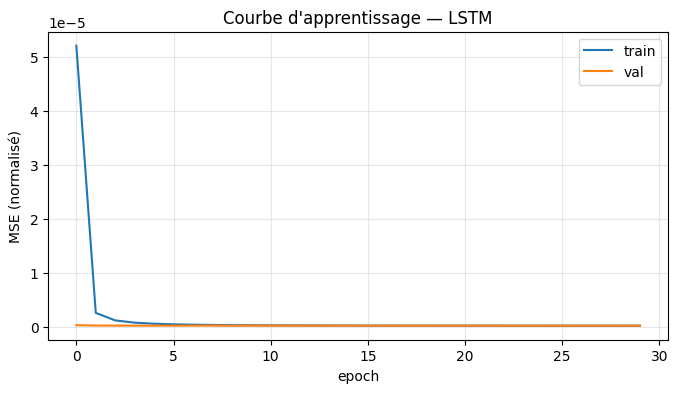

In [44]:
# Courbes d'apprentissage
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE (normalisé)")
plt.title("Courbe d'apprentissage — LSTM"); plt.legend(); plt.grid(alpha=.3); plt.show()

## 8. Évaluation sur le jeu de test
On repasse les prédictions et la vérité en unités physiques (°C) via l'inverse du
scaler, puis on calcule RMSE / MAE / R² — globalement et par horizon J+1..J+OUTPUT_WINDOW.

In [45]:
def inv_y(arr):
    """[N, OUTPUT_WINDOW] normalisé -> physique (°C)."""
    flat = scaler_y.inverse_transform(arr.reshape(-1, 1))
    return flat.reshape(arr.shape)

pred = inv_y(model.predict(X_te, batch_size=BATCH_SIZE, verbose=0))
true = inv_y(y_te)

# Métriques globales (toutes positions d'horizon confondues)
rmse = math.sqrt(mean_squared_error(true.ravel(), pred.ravel()))
mae  = mean_absolute_error(true.ravel(), pred.ravel())
r2   = r2_score(true.ravel(), pred.ravel())
print(f"heat_index (test) — RMSE={rmse:.3f} °C | MAE={mae:.3f} °C | R²={r2:.3f}")

# Métriques par horizon
rows = []
for h in range(OUTPUT_WINDOW):
    rows.append({
        "horizon": f"J+{h+1}",
        "RMSE": round(math.sqrt(mean_squared_error(true[:, h], pred[:, h])), 3),
        "MAE":  round(mean_absolute_error(true[:, h], pred[:, h]), 3),
        "R2":   round(r2_score(true[:, h], pred[:, h]), 3),
    })
metrics_df = pd.DataFrame(rows).set_index("horizon")
print(metrics_df.to_string())
metrics_df

heat_index (test) — RMSE=0.047 °C | MAE=0.034 °C | R²=0.648
          RMSE    MAE     R2
horizon                     
J+1      0.040  0.028  0.742
J+2      0.045  0.033  0.678
J+3      0.047  0.034  0.649
J+4      0.048  0.036  0.632
J+5      0.049  0.036  0.620
J+6      0.050  0.036  0.612
J+7      0.050  0.037  0.602


,RMSE,MAE,R2
horizon,,,
J+1,0.040,0.028,0.742
J+2,0.045,0.033,0.678
J+3,0.047,0.034,0.649
J+4,0.048,0.036,0.632
J+5,0.049,0.036,0.620
J+6,0.050,0.036,0.612
J+7,0.050,0.037,0.602


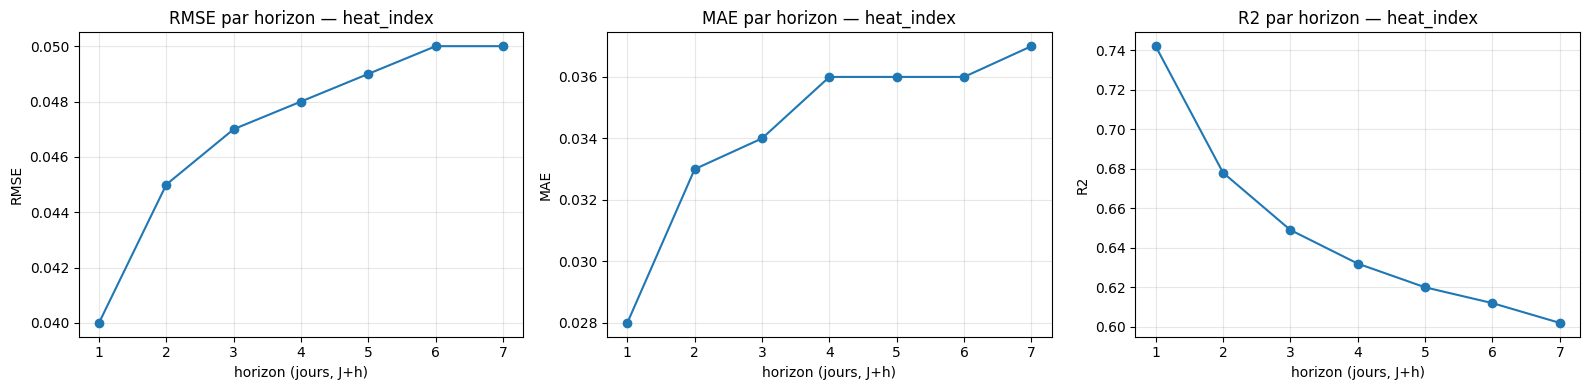

In [46]:
# Métriques par horizon — visualisation
h = np.arange(1, OUTPUT_WINDOW + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["RMSE", "MAE", "R2"]):
    ax.plot(h, metrics_df[col].values, marker="o")
    ax.set_title(f"{col} par horizon — heat_index")
    ax.set_xlabel("horizon (jours, J+h)"); ax.set_ylabel(col); ax.set_xticks(h); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 9. Prédictions vs réel (J+1 sur le jeu de test)

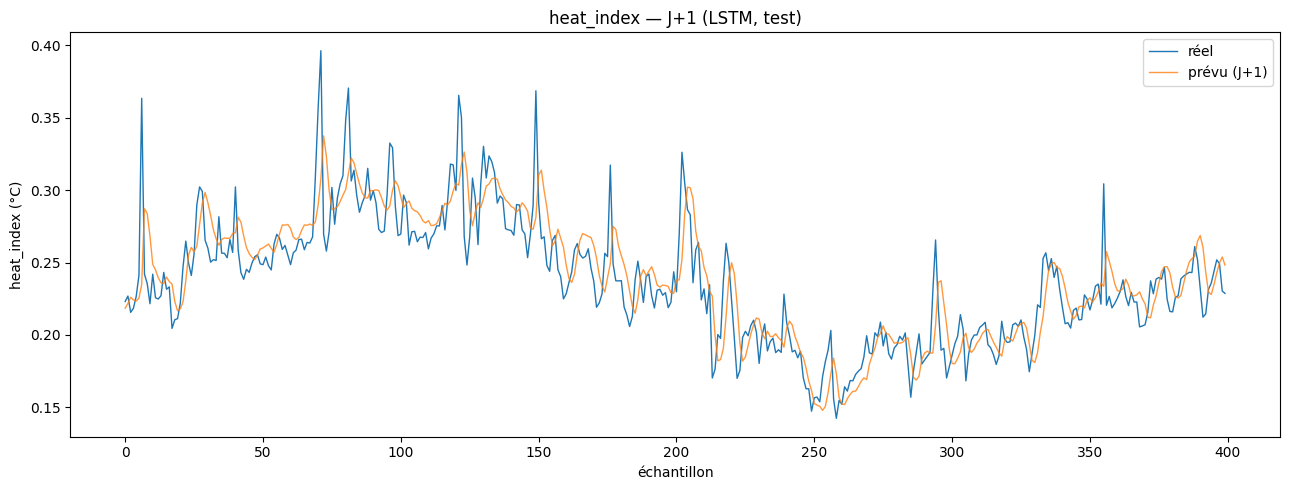

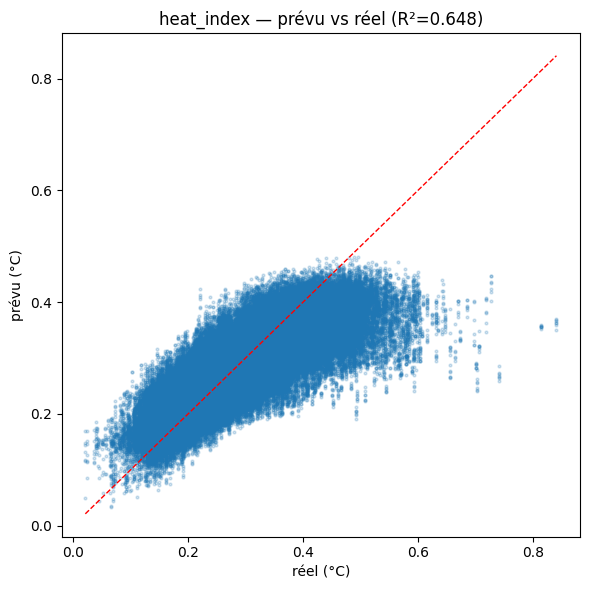

In [47]:
plt.figure(figsize=(13, 5))
n = min(400, pred.shape[0])
plt.plot(true[:n, 0], label="réel", lw=1)
plt.plot(pred[:n, 0], label="prévu (J+1)", lw=1, alpha=0.8)
plt.title("heat_index — J+1 (LSTM, test)"); plt.legend()
plt.xlabel("échantillon"); plt.ylabel("heat_index (°C)")
plt.tight_layout(); plt.show()

# Nuage prévu vs réel (tous horizons)
plt.figure(figsize=(6, 6))
plt.scatter(true.ravel(), pred.ravel(), s=4, alpha=0.2)
lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
plt.plot(lims, lims, "r--", lw=1)
plt.xlabel("réel (°C)"); plt.ylabel("prévu (°C)")
plt.title(f"heat_index — prévu vs réel (R²={r2:.3f})")
plt.tight_layout(); plt.show()

## 10. Sauvegarde des artefacts

In [48]:
model.save(str(ART_DIR / "lstm_heat_index.keras"))
joblib.dump(scaler_X, ART_DIR / "scaler_X.pkl")
joblib.dump(scaler_y, ART_DIR / "scaler_y.pkl")
metrics_df.to_csv(ART_DIR / "metrics_by_horizon.csv")

meta = {
    "framework": "tensorflow", "model": "LSTM",
    "features": FEATURES, "target": TARGET,
    "scaler": "minmax", "feature_range": [0, 1],
    "split": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO,
              "scheme": "per-station chronological"},
    "input_window": INPUT_WINDOW, "output_window": OUTPUT_WINDOW,
    "hidden": HIDDEN, "n_layers": N_LAYERS, "dropout": DROPOUT,
    "metrics_overall": {"rmse": round(rmse, 3), "mae": round(mae, 3), "r2": round(r2, 3)},
    "dataset": "data/cleandata_gsod_by_station",
}
json.dump(meta, open(ART_DIR / "lstm_meta.json", "w"), indent=2)
print("Sauvegardé ->", ART_DIR)
print("  lstm_heat_index.keras | scaler_X.pkl | scaler_y.pkl | metrics_by_horizon.csv | lstm_meta.json")

Sauvegardé -> artifacts
  lstm_heat_index.keras | scaler_X.pkl | scaler_y.pkl | metrics_by_horizon.csv | lstm_meta.json
